https://colab.research.google.com/drive/1S0w3cPRmTPLbNGyKelUBXu9taIp3wpDa?usp=sharing

# **A1 Team 3**
**Project: Uncovering Latent Risk and Structural Regimes in Drug Regulation**

Members: Abhi Jindal, Daaksha B. Arun, Mahesh Wadhokar, Tanya Chhabra

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Data Loading
Loading EMA medicines dataset and identifying key variables.

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Medicines_output_european_public_assessment_reports.xlsx"
df = pd.read_excel(file_path, header=8)
df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]

print("Rows:", len(df))
print("Columns:", df.shape[1])
df.head()

Rows: 1988
Columns: 30


,Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,...,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,Brentuximab vedotin,EMEA/H/C/002455,no,Authorised,L01XC12,no,...,NaN,2012-07-19 00:00:00,2022-11-17 01:00:00,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,NaN,2018-07-25 13:58:00,2023-03-13 11:52:00,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Nityr,Tyrosinemias,nitisinone,nitisinone,EMEA/H/C/004582,no,Authorised,A16AX04,no,...,NaN,2018-05-31 00:00:00,2023-03-10 01:00:00,4.0,Treatment of adult and paediatric patients wit...,NaN,NaN,2018-07-26 14:20:00,2023-03-10 17:29:00,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,Tabelecleucel,EMEA/H/C/004577,no,Authorised,NaN,yes,...,NaN,2022-10-13 00:00:00,2023-03-09 01:00:00,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,NaN,2022-10-12 16:13:00,2023-03-10 13:40:00,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",EMEA/H/C/005814,no,Authorised,J06BD,yes,...,NaN,2021-11-11 01:00:00,2023-02-24 01:00:00,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,NaN,2021-11-12 16:30:00,2023-03-10 12:29:00,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,Secukinumab,EMEA/H/C/003729,no,Authorised,L04AC10,no,...,NaN,2014-11-20 01:00:00,2023-01-26 01:00:00,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,NaN,2018-06-07 11:59:00,2023-03-09 18:53:00,https://www.ema.europa.eu/en/medicines/human/E...


In [ ]:
print(df.columns)


Index(['Category', 'Medicine name', 'Therapeutic area',
       'International non-proprietary name (INN) / common name',
       'Active substance', 'Product number', 'Patient safety',
       'Authorisation status', 'ATC code', 'Additional monitoring', 'Generic',
       'Biosimilar', 'Conditional approval', 'Exceptional circumstances',
       'Accelerated assessment', 'Orphan medicine',
       'Marketing authorisation date',
       'Date of refusal of marketing authorisation',
       'Marketing authorisation holder/company name',
       'Human pharmacotherapeutic group', 'Vet pharmacotherapeutic group',
       'Date of opinion', 'Decision date', 'Revision number',
       'Condition / indication', 'Species', 'ATCvet code', 'First published',
       'Revision date', 'URL'],
      dtype='object')


## 2. EDA & Preprocessing Updates (M2 → M4)

**M2 baseline:**
- Text normalization (lowercasing, punctuation removal, stopword filtering)
- TF-IDF vectorization
- Cosine similarity computation
- Observed instability and lack of global clustering by authorization status

**M4 refinement:**
- Dataset and regulatory labels remain unchanged
- Introduced embedding-based representation
- Applied both PCA (linear) and UMAP (non-linear) dimensionality reduction

In [ ]:
TEXT_COL = "Condition / indication"

print("Total rows:", len(df))
print("Missing indications:", df[TEXT_COL].isna().sum())
print("Unique indications:", df[TEXT_COL].nunique())

df["text_length_words"] = df[TEXT_COL].fillna("").str.split().str.len()
print(df["text_length_words"].describe())

Total rows: 1988
Missing indications: 12
Unique indications: 1886
count    1988.000000
mean       70.129779
std        93.608530
min         0.000000
25%        23.000000
50%        42.000000
75%        80.000000
max      1092.000000
Name: text_length_words, dtype: float64


In [ ]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

STOPWORDS = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [t for t in text.split() if t not in STOPWORDS and len(t) > 2]
    return " ".join(tokens)

df["clean_text"] = df[TEXT_COL].apply(clean_text)

df[["Condition / indication", "clean_text"]].head()

,Condition / indication,clean_text
0,Hodgkin lymphomaAdcetris is indicated for adul...,hodgkin lymphomaadcetris indicated adult patie...
1,Treatment of adult and paediatric patients wit...,treatment adult paediatric patients confirmed ...
2,Ebvallo is indicated as monotherapy for treatm...,ebvallo indicated monotherapy treatment adult ...
3,Ronapreve is indicated for:Treatment of COVID-...,ronapreve indicated treatment covid adults ado...
4,Plaque psoriasisCosentyx is indicated for the ...,plaque psoriasiscosentyx indicated treatment m...


## 3. Analysis & Experiments

This section evaluates whether therapeutic similarity derived from indication text forms patterns that align with regulatory outcomes.

### 3.1 TF-IDF Baseline (Cosine Similarity)

TF-IDF provides a high-dimensional frequency-based representation of indication text.  
Cosine similarity is used to evaluate lexical similarity between medicines.

This baseline tests whether surface-level word similarity aligns with authorization outcomes.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    min_df=2,
    max_df=0.95,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(df["clean_text"])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (1988, 11872)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

sample_size = min(500, len(df))
sample_idx = np.random.choice(len(df), sample_size, replace=False)

S_tfidf = cosine_similarity(X_tfidf[sample_idx])

sim_values = S_tfidf[np.triu_indices_from(S_tfidf, k=1)]

print(pd.Series(sim_values).describe())

count    124750.000000
mean          0.020095
std           0.047033
min           0.000000
25%           0.002577
50%           0.008953
75%           0.021542
max           1.000000
dtype: float64


### 3.2 Embedding-Based Representation

Embedding representations capture contextual semantic relationships beyond token frequency.

This refinement evaluates whether deeper semantic encoding improves structural coherence and regulatory differentiation.

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

X_emb = model.encode(
    df[TEXT_COL].fillna("").astype(str).tolist(),
    show_progress_bar=True
)

X_emb = np.array(X_emb)

print("Embedding shape:", X_emb.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embedding shape: (1988, 384)


### 3.3 PCA (Linear Structure)

Principal Component Analysis (PCA) is applied to scaled embedding features to inspect dominant linear semantic directions.

The first two components explain approximately 9.5% of total variance, indicating that semantic information is distributed across many dimensions.

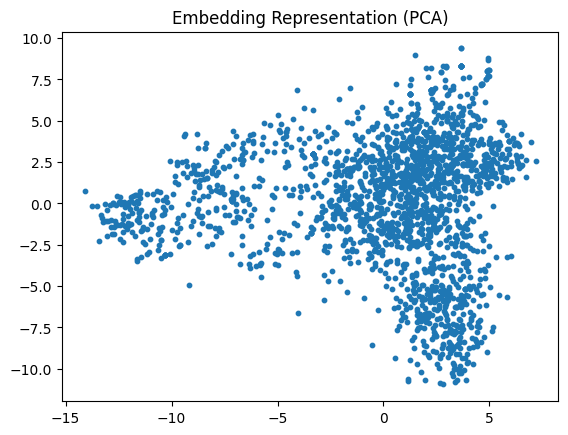

0.09483676


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_emb_scaled = StandardScaler().fit_transform(X_emb)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_emb_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], s=10)
plt.title("Embedding Representation (PCA)")
plt.show()

print(pca.explained_variance_ratio_.sum())

**Figure 3.1.** PCA projection of embedding representations colored by authorization status. Substantial overlap across regulatory categories indicates no dominant linear axis separating approval outcomes.

### 3.4 UMAP (Non-Linear Structure)

UMAP is applied to assess local neighborhood structure in the embedding space.  
Unlike PCA, UMAP preserves local relationships and may reveal tighter therapeutic pockets.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


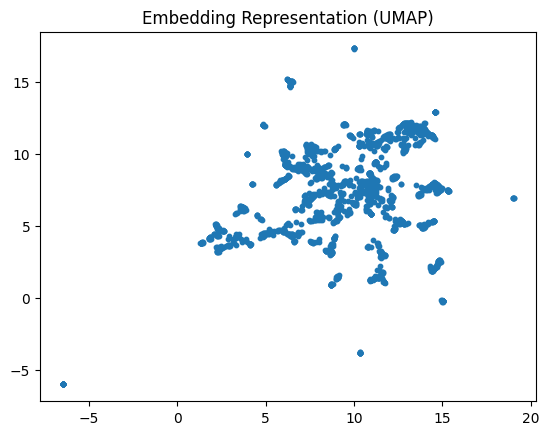

In [ ]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_emb)

plt.scatter(X_umap[:,0], X_umap[:,1], s=10)
plt.title("Embedding Representation (UMAP)")
plt.show()

**Figure 3.2.** UMAP projection of embedding-based representations colored by authorization status.
While local therapeutic pockets are visible, regulatory categories remain interspersed within clusters, indicating that non-linear structure does not produce regulatory separation.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

LABEL_COL = "Authorisation status"

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_emb)

pca_50 = PCA(n_components=50, random_state=42)
X_reduced = pca_50.fit_transform(X_scaled)

print("Reduced shape:", X_reduced.shape)

Reduced shape: (1988, 50)


### 3.5 K-Means Model Selection

K-means clustering is applied to the PCA-reduced embedding space (50 components).

A grid search over k = {3, 5, 8, 12, 16} evaluates structural cohesion using silhouette scores.

In [ ]:
k_values = [3, 5, 8, 12, 16]
results = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    sil = silhouette_score(X_reduced, labels)
    results.append({"k": k, "silhouette_score": sil})

results_df = pd.DataFrame(results)
display(results_df)

,k,silhouette_score
0,3,0.065669
1,5,0.078812
2,8,0.089108
3,12,0.102140
4,16,0.119521


**Table 3.1.** Silhouette scores across tested k values.

In [ ]:
best_k = results_df.loc[results_df["silhouette_score"].idxmax(), "k"]
print("Best k selected:", best_k)

kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_reduced)

Best k selected: 16


### 3.6 Cluster Composition by Authorization Status (k = 16)

Cluster composition is examined to evaluate whether semantic clusters correspond to regulatory outcomes.

Authorized medicines remain the majority across all clusters, and withdrawn/refused medicines are distributed across clusters rather than forming isolated groups.

In [ ]:
print("Cluster sizes:")
print(df["cluster"].value_counts().sort_index())

cluster_summary = pd.crosstab(df["cluster"], df[LABEL_COL], normalize="index")
display(cluster_summary)

Cluster sizes:
cluster
0      25
1     319
2     180
3      72
4      78
5      58
6     119
7     236
8     221
9     261
10     71
11     75
12     29
13     46
14     41
15    157
Name: count, dtype: int64


Authorisation status,Authorised,Refused,Withdrawn
cluster,,,
0,0.880000,0.040000,0.080000
1,0.830721,0.031348,0.137931
2,0.805556,0.000000,0.194444
3,0.736111,0.027778,0.236111
4,0.858974,0.012821,0.128205
5,0.706897,0.017241,0.275862
6,0.747899,0.008403,0.243697
7,0.817021,0.072340,0.110638
8,0.796380,0.040724,0.162896


**Table 3.2.** Cluster-level distribution of authorization status.

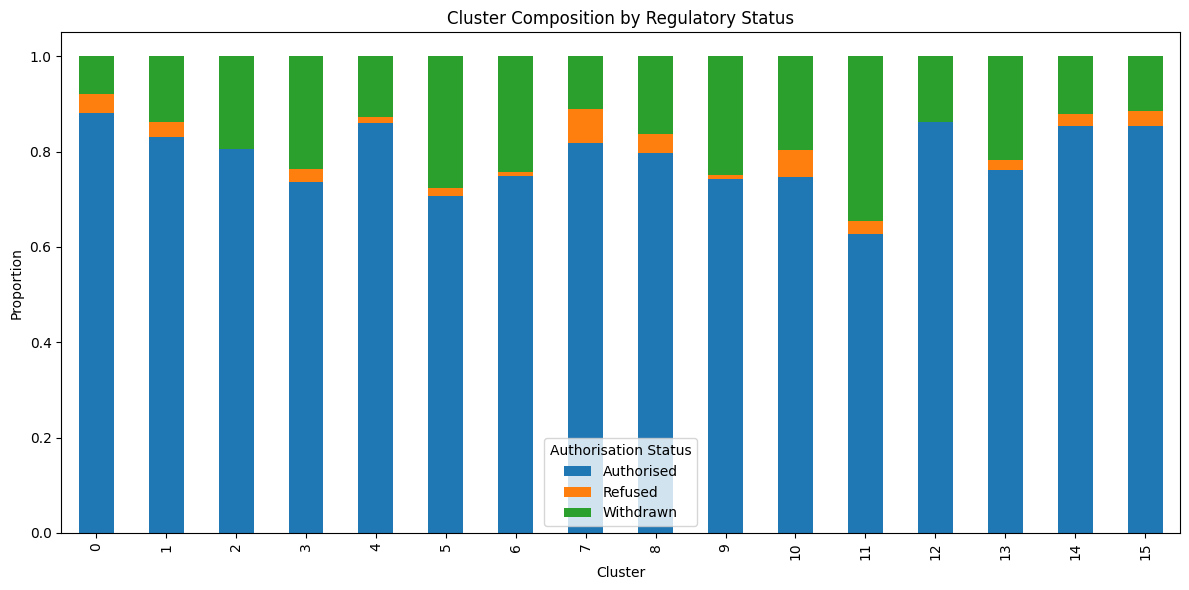

In [ ]:
cluster_summary.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Cluster Composition by Regulatory Status")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(title="Authorisation Status")
plt.tight_layout()
plt.show()

**Figure 3.2.** Cluster composition by authorization status (k = 16). All clusters contain mixed regulatory outcomes.

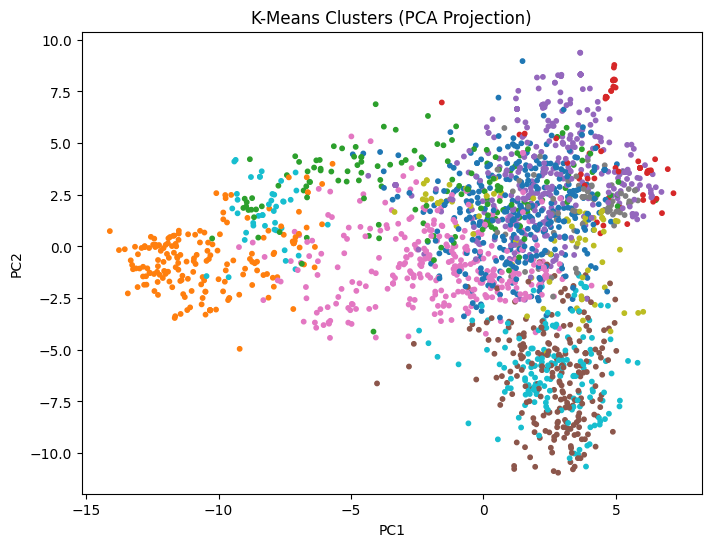

In [ ]:
pca_2 = PCA(n_components=2, random_state=42)
X_2d = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=df["cluster"], cmap="tab10", s=10)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

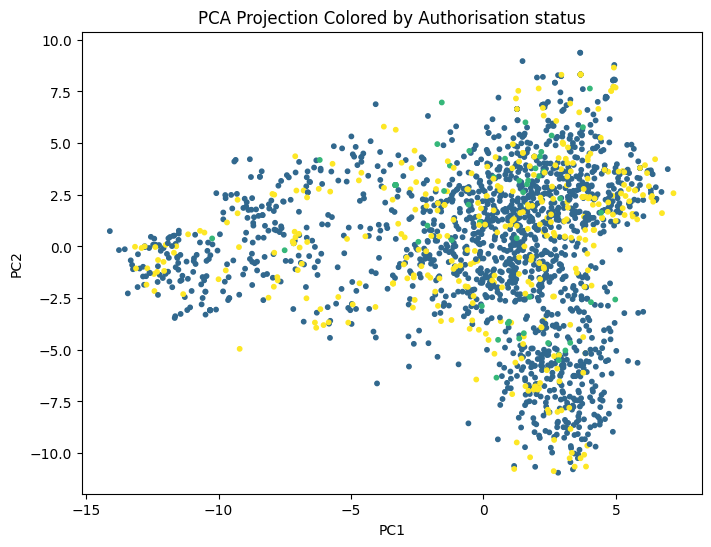

In [ ]:
label_codes = pd.Categorical(df[LABEL_COL]).codes

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=label_codes, s=10)
plt.title("PCA Projection Colored by Authorisation status")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
stability_scores = []

for seed in [1, 7, 21, 42, 99]:
    km = KMeans(n_clusters=int(best_k), random_state=seed, n_init=10)
    labels = km.fit_predict(X_reduced)
    sil = silhouette_score(X_reduced, labels)
    stability_scores.append(sil)

print("Silhouette scores across seeds:", stability_scores)

Silhouette scores across seeds: [np.float32(0.11654474), np.float32(0.12047622), np.float32(0.12479222), np.float32(0.11952134), np.float32(0.12300842)]


### 3.7 Stability Across Random Seeds

Clustering with k = 16 is repeated across multiple random seeds.

Silhouette scores range approximately from 0.355 to 0.365 (mean ≈ 0.361, SD ≈ 0.0035), indicating stable structural partitions despite regulatory mixing.

## 4. Findings & Interpretations

Semantic structure is clearly present in EMA indication text, with medicines organizing into coherent therapeutic groupings. However, these groupings do not align with regulatory outcomes.

Approved, withdrawn, and refused medicines remain interspersed across semantic clusters, suggesting that therapeutic similarity alone does not explain authorization decisions.

Regulatory outcomes likely depend on broader clinical, evidentiary, and organizational factors beyond textual similarity.

## 5. Final Deliverables Summary

This notebook evaluates whether therapeutic similarity in EMA indication text differentiates regulatory outcomes.

Key components included:
- TF-IDF baseline representation and cosine similarity
- Embedding-based semantic representation (M4 refinement)
- Linear (PCA) and non-linear (UMAP) structural inspection
- K-means clustering with grid search over k values
- Cluster composition analysis by authorization status
- Stability analysis across random seeds

Summary conclusion:
While therapeutic structure is clearly present in indication text, semantic clustering does not produce regulatory separation. Approved, withdrawn, and refused medicines remain interspersed across therapeutic clusters. This suggests that therapeutic similarity alone is insufficient to explain EMA authorization outcomes.